# Phases 3–4 — Leakage audit and data cleaning

**Input:** `data/sample.parquet` · **Output:** `data/clean.parquet`, `reports/leakage_audit.md`, `reports/cleaning_log.md`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA, REPORTS = Path("../data"), Path("../reports")
FIGS = REPORTS / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

ROAD = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
        "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop"]
LIGHT = ["Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]
WEATHER = ["Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
           "Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)", "Weather_Condition"]


def to_md(t):
    """DataFrame -> markdown table (avoids the optional `tabulate` dependency)."""
    rows = [t.columns.tolist(), ["---"] * t.shape[1], *t.astype(str).values.tolist()]
    return "\n".join("| " + " | ".join(map(str, r)) + " |" for r in rows)


df = pd.read_parquet(DATA / "sample.parquet")
log = []  # cleaning log: shape after every step


def step(name, note=""):
    log.append({"step": name, "rows": len(df), "cols": df.shape[1], "note": note})


step("Load sample.parquet")
df.shape

(500000, 46)

# Phase 3 — Leakage audit

Rule: **a column is allowed only if its value is known at the moment the accident is first reported.**

First, proof that the suspected columns really carry the answer:

In [2]:
start = pd.to_datetime(df["Start_Time"], format="mixed")
end = pd.to_datetime(df["End_Time"], format="mixed")
by_sev = df.groupby("Severity")
pd.DataFrame({
    "median_duration_min": ((end - start).dt.total_seconds() / 60).groupby(df["Severity"]).median(),
    "mean_distance_mi": by_sev["Distance(mi)"].mean(),
    "desc_mentions_closed_%": df["Description"].str.contains("closed", case=False, na=False)
                                .groupby(df["Severity"]).mean() * 100,
}).round(2)

,median_duration_min,mean_distance_mi,desc_mentions_closed_%
Severity,,,
1,44.77,0.11,2.22
2,77.55,0.57,4.72
3,44.40,0.42,5.39
4,129.20,1.48,88.53


In [3]:
CARE = "Keep with care: high cardinality, encode in Phase 6 (no one-hot)"
turning_const = df["Turning_Loop"].nunique() == 1
DECISIONS = {  # column -> (decision, reason); every other column is kept
    "End_Time":          ("drop", "Leakage: known only after the road is cleared (duration ≈ delay ≈ severity)"),
    "End_Lat":           ("drop", "Leakage: end of the affected stretch, measured afterwards"),
    "End_Lng":           ("drop", "Leakage: end of the affected stretch, measured afterwards"),
    "Distance(mi)":      ("drop", "Leakage: length of road affected is part of how severity is judged"),
    "Description":       ("drop", "Leakage: free text says 'road closed' / 'lanes blocked'"),
    "ID":                ("drop", "Identifier only, no information"),
    "Country":           ("drop", "Constant (always 'US')"),
    "Turning_Loop":      ("drop", "Constant (single value)") if turning_const else ("keep", "Road feature, not constant"),
    "Weather_Timestamp": ("drop", "Redundant with Start_Time"),
    "Timezone":          ("drop", "Redundant with location (State)"),
    "Airport_Code":      ("drop", "Redundant with location (nearest weather station)"),
    "Source":            ("keep (analysis)", "Providers may record severity differently; with/without ablation in Phase 9"),
    **dict.fromkeys(["Street", "City", "County", "Zipcode"], ("keep (care)", CARE)),
}


def default(col):
    group = ("target" if col == "Severity" else "road feature" if col in ROAD else "light" if col in LIGHT
             else "weather" if col in WEATHER else "time" if col == "Start_Time" else "location")
    return ("keep", f"Known at report time ({group})")


audit = pd.DataFrame(
    [(c, *DECISIONS.get(c, default(c)), df[c].nunique(), round(df[c].isna().mean() * 100, 2)) for c in df.columns],
    columns=["column", "decision", "reason", "n_unique", "missing_%"],
)
assert df["Country"].nunique() == 1 and turning_const  # constants verified on the data
audit

,column,decision,reason,n_unique,missing_%
0,ID,drop,"Identifier only, no information",500000,0.00
1,Source,keep (analysis),Providers may record severity differently; wit...,3,0.00
2,Severity,keep,Known at report time (target),4,0.00
3,Start_Time,keep,Known at report time (time),487027,0.00
4,End_Time,drop,Leakage: known only after the road is cleared ...,493821,0.00
5,Start_Lat,keep,Known at report time (location),368965,0.00
6,Start_Lng,keep,Known at report time (location),370195,0.00
7,End_Lat,drop,"Leakage: end of the affected stretch, measured...",220333,44.08
8,End_Lng,drop,"Leakage: end of the affected stretch, measured...",221463,44.08
9,Distance(mi),drop,Leakage: length of road affected is part of ho...,10627,0.00


In [4]:
(REPORTS / "leakage_audit.md").write_text(
    "# Phase 3 — Leakage audit\n\n"
    "Rule: a column is kept only if its value is known when the accident is first reported.\n\n"
    + to_md(audit) + "\n", encoding="utf-8")

df = df.drop(columns=audit.loc[audit["decision"] == "drop", "column"])
ROAD = [c for c in ROAD if c in df]
step("Phase 3: drop leakage / ID / constant / redundant columns",
     ", ".join(audit.loc[audit["decision"] == "drop", "column"]))
df.shape

(500000, 35)

# Phase 4 — Data cleaning
## 4.1 Types and duplicates
`format="mixed"` handles the rows with fractional seconds that break a single fixed format.

In [5]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed")
df[ROAD] = df[ROAD].astype("int8")
step("4.1 Parse Start_Time; road flags True/False -> 0/1")

n_dup = int(df.duplicated().sum())
df = df.drop_duplicates(ignore_index=True)
step("4.1 Drop exact duplicate rows", f"{n_dup} removed")
n_dup

2884

## 4.2 Missing values

In [6]:
missing = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
missing[missing > 0].to_frame("missing_%")

,missing_%
Precipitation(in),28.66
Wind_Chill(F),25.93
Wind_Speed(mph),7.42
Visibility(mi),2.26
Wind_Direction,2.24
Humidity(%),2.23
Weather_Condition,2.22
Temperature(F),2.09
Pressure(in),1.79
Civil_Twilight,0.30


In [7]:
# Wind_Chill is close to a copy of Temperature
df[["Temperature(F)", "Wind_Chill(F)"]].corr().round(3)

,Temperature(F),Wind_Chill(F)
Temperature(F),1.000,0.994
Wind_Chill(F),0.994,1.000


In [8]:
too_empty = missing[missing > 40].index.tolist()
dropped = too_empty + ["Wind_Chill(F)"]
df = df.drop(columns=dropped)
step("4.2 Drop columns >40% missing + Wind_Chill(F)", ", ".join(dropped))

# Missing precipitation is mostly "no rain reported" -> 0, keep a flag so the model can tell
df["precip_missing"] = df["Precipitation(in)"].isna().astype("int8")
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0.0)
step("4.2 Precipitation NaN -> 0 + precip_missing flag", f"{df['precip_missing'].sum()} filled")

n0 = len(df)
df = df.dropna(subset=["City", "Zipcode", *LIGHT], ignore_index=True)
step("4.2 Drop rows missing City / Zipcode / light columns", f"{n0 - len(df)} rows removed")

df[["Weather_Condition", "Wind_Direction"]] = df[["Weather_Condition", "Wind_Direction"]].fillna("Unknown")
step("4.2 Weather_Condition, Wind_Direction NaN -> 'Unknown'")
# Temperature, Humidity, Pressure, Visibility, Wind_Speed stay NaN: median-imputed in the Phase 9 Pipeline (train only)

## 4.3 Outliers and impossible values
Values outside these limits are physically impossible for a US road; they are set to NaN
(imputed later inside the Pipeline, like any other missing value).

In [9]:
LIMITS = {  # column: (low, high, reason)
    "Temperature(F)":  (-50, 130, "US record high is 134 °F; below −50 °F is not plausible on US roads in this data"),
    "Wind_Speed(mph)": (0, 200, "Above the strongest surface winds ever measured outside tornadoes"),
    "Visibility(mi)":  (0, 100, "Weather stations do not report visibility above ~100 mi"),
    "Pressure(in)":    (15, 32, "Highest US roads (~14,000 ft) ≈ 17.5 inHg; world record high 32.06 inHg"),
}
cols = list(LIMITS)
df[cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Temperature(F),485407.0,61.64,18.99,-77.80,49.00,64.00,76.00,207.00
Wind_Speed(mph),458916.0,7.68,5.43,0.00,4.60,7.00,10.40,822.80
Visibility(mi),484593.0,9.09,2.71,0.00,10.00,10.00,10.00,130.00
Pressure(in),486938.0,29.54,1.01,0.12,29.37,29.86,30.03,38.44


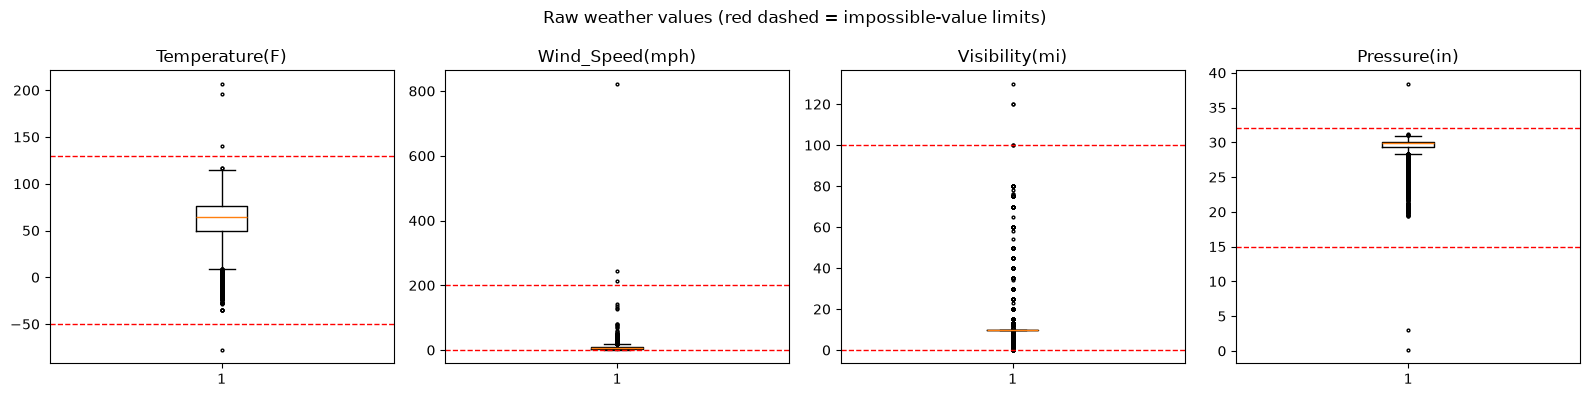

In [10]:
fig, axes = plt.subplots(1, len(cols), figsize=(16, 4))
for ax, c in zip(axes, cols):
    ax.boxplot(df[c].dropna(), flierprops={"markersize": 2})
    ax.axhline(LIMITS[c][0], color="r", ls="--", lw=1)
    ax.axhline(LIMITS[c][1], color="r", ls="--", lw=1)
    ax.set_title(c)
fig.suptitle("Raw weather values (red dashed = impossible-value limits)")
fig.tight_layout()
fig.savefig(FIGS / "outliers_boxplots.png", dpi=120)

In [11]:
n_bad = {}
for c, (lo, hi, _) in LIMITS.items():
    bad = df[c].notna() & ~df[c].between(lo, hi)
    n_bad[c] = int(bad.sum())
    df.loc[bad, c] = np.nan
step("4.3 Impossible weather values -> NaN", ", ".join(f"{c}: {n}" for c, n in n_bad.items()))
assert all(df[c].dropna().between(lo, hi).all() for c, (lo, hi, _) in LIMITS.items())
n_bad

{'Temperature(F)': 4,
 'Wind_Speed(mph)': 3,
 'Visibility(mi)': 3,
 'Pressure(in)': 3}

## 4.4 Standardise categories

In [12]:
COMPASS = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
WIND = {"Calm": "CALM", "Variable": "VAR", "North": "N", "South": "S", "East": "E", "West": "W"}

df["Wind_Direction"] = df["Wind_Direction"].replace(WIND)
assert set(df["Wind_Direction"]) <= {*COMPASS, "CALM", "VAR", "Unknown"}
step("4.4 Wind_Direction -> 16 compass points + CALM + VAR", f"{df['Wind_Direction'].nunique()} values")
df["Wind_Direction"].value_counts()

Wind_Direction
CALM       85671
S          38254
W          35361
N          29552
SSW        24597
E          24293
WNW        24110
NW         23699
SW         23476
VAR        23456
WSW        22677
SSE        22443
NNW        21389
SE         18993
ESE        16974
NE         16725
ENE        16527
NNE        16504
Unknown    10831
Name: count, dtype: int64

In [13]:
WEATHER_GROUPS = [  # first match wins, so order = priority (worst condition first)
    ("Heavy rain / Thunderstorm", ("thunder", "t-storm", "heavy rain", "tornado", "funnel", "hail")),
    ("Snow / Ice",                ("snow", "sleet", "ice", "wintry", "freezing rain", "freezing drizzle")),
    ("Rain",                      ("rain", "drizzle", "shower")),
    ("Fog / Haze / Smoke",        ("fog", "haze", "smoke", "mist", "dust", "sand", "ash")),
    ("Windy",                     ("windy", "squall")),
    ("Cloudy",                    ("cloud", "overcast")),
    ("Clear",                     ("fair", "clear")),
]


def weather_group(label):
    if label == "Unknown":
        return label
    s = label.lower()
    return next((g for g, keys in WEATHER_GROUPS if any(k in s for k in keys)), "Other")


labels = df["Weather_Condition"].unique()  # ~100 labels: map once per label, not per row
df["Weather_Group"] = df["Weather_Condition"].map({l: weather_group(l) for l in labels})
step("4.4 Weather_Condition -> Weather_Group", f"{len(labels)} labels -> {df['Weather_Group'].nunique()} groups")

weather_map = (df.groupby("Weather_Group")
                 .agg(rows=("Weather_Condition", "size"),
                      labels=("Weather_Condition", lambda s: ", ".join(s.value_counts().index)))
                 .sort_values("rows", ascending=False))
weather_map

,rows,labels
Weather_Group,,
Clear,216488,"Fair, Clear"
Cloudy,200063,"Mostly Cloudy, Cloudy, Partly Cloudy, Overcast..."
Rain,30629,"Light Rain, Rain, Light Drizzle, Light Rain / ..."
Fog / Haze / Smoke,13084,"Fog, Haze, Smoke, Patches of Fog, Mist, Shallo..."
Snow / Ice,11278,"Light Snow, Snow, Wintry Mix, Light Snow / Win..."
Unknown,10750,Unknown
Heavy rain / Thunderstorm,7882,"Heavy Rain, Thunder in the Vicinity, T-Storm, ..."
Windy,5155,"Fair / Windy, Mostly Cloudy / Windy, Cloudy / ..."
Other,203,N/A Precipitation


## Final types and save

In [14]:
CATS = ["Source", "State", "Wind_Direction", "Weather_Condition", "Weather_Group", *LIGHT]
df[CATS] = df[CATS].astype("category")
df["Severity"] = df["Severity"].astype("int8")

df.to_parquet(DATA / "clean.parquet", index=False)
step("Save clean.parquet")
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 495532 entries, 0 to 495531
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Source                 495532 non-null  category      
 1   Severity               495532 non-null  int8          
 2   Start_Time             495532 non-null  datetime64[ns]
 3   Start_Lat              495532 non-null  float64       
 4   Start_Lng              495532 non-null  float64       
 5   Street                 494859 non-null  str           
 6   City                   495532 non-null  str           
 7   County                 495532 non-null  str           
 8   State                  495532 non-null  category      
 9   Zipcode                495532 non-null  str           
 10  Temperature(F)         485403 non-null  float64       
 11  Humidity(%)            484751 non-null  float64       
 12  Pressure(in)           486935 non-null  float64       


In [15]:
left = df.isna().sum()
left[left > 0].to_frame("NaN left (imputed in Phase 9 Pipeline)")

,NaN left (imputed in Phase 9 Pipeline)
Street,673
Temperature(F),10129
Humidity(%),10781
Pressure(in),8597
Visibility(mi),10942
Wind_Speed(mph),36619


In [16]:
log_df = pd.DataFrame(log)
log_df.insert(2, "Δrows", log_df["rows"].diff().fillna(0).astype(int))
log_df.insert(4, "Δcols", log_df["cols"].diff().fillna(0).astype(int))

limits_df = pd.DataFrame([(c, lo, hi, n_bad[c], why) for c, (lo, hi, why) in LIMITS.items()],
                         columns=["column", "low", "high", "set_to_NaN", "reason"])
(REPORTS / "cleaning_log.md").write_text("\n\n".join([
    "# Phase 4 — Cleaning log",
    "## Steps (shape after each step)", to_md(log_df),
    "## Missing values before 4.2 (%)", to_md(missing[missing > 0].reset_index().set_axis(["column", "missing_%"], axis=1)),
    "## Impossible-value thresholds (4.3)", to_md(limits_df),
    "## Wind_Direction merges (4.4)", to_md(pd.DataFrame(WIND.items(), columns=["raw", "standard"])),
    "## Weather_Condition -> Weather_Group (4.4)", to_md(weather_map.reset_index()),
    "## NaN left for Pipeline imputation (Phase 9)", to_md(left[left > 0].reset_index().set_axis(["column", "NaN"], axis=1)),
]) + "\n", encoding="utf-8")
log_df

,step,rows,Δrows,cols,Δcols,note
0,Load sample.parquet,500000,0,46,0,
1,Phase 3: drop leakage / ID / constant / redund...,500000,0,35,-11,"ID, End_Time, End_Lat, End_Lng, Distance(mi), ..."
2,4.1 Parse Start_Time; road flags True/False ->...,500000,0,35,0,
3,4.1 Drop exact duplicate rows,497116,-2884,35,0,2884 removed
4,4.2 Drop columns >40% missing + Wind_Chill(F),497116,0,34,-1,Wind_Chill(F)
5,4.2 Precipitation NaN -> 0 + precip_missing flag,497116,0,35,1,142481 filled
6,4.2 Drop rows missing City / Zipcode / light c...,495532,-1584,35,0,1584 rows removed
7,"4.2 Weather_Condition, Wind_Direction NaN -> '...",495532,0,35,0,
8,4.3 Impossible weather values -> NaN,495532,0,35,0,"Temperature(F): 4, Wind_Speed(mph): 3, Visibil..."
9,4.4 Wind_Direction -> 16 compass points + CALM...,495532,0,35,0,19 values
